# 09 · Generation and Cache: Measure It

**Hardware**: 🟡 24GB VRAM, `google/gemma-4-E2B-it`.

Everything before this chapter described a single forward pass. Generation is that pass in a loop, and almost all of the engineering is about not redoing work. This notebook measures what [chapter 06](../../06-text-decoder/index.md)'s attention design actually buys.

## What you will do

1. Watch the KV cache **saturate** for sliding layers while global layers grow linearly
2. Confirm the cache has fewer entries than the model has layers
3. Measure batch scaling and see why decode is nearly free to batch
4. Time the static cache honestly — including its compilation cost
5. Stream tokens, and measure what thinking mode costs

In [1]:
%pip install -q "transformers>=5.14" accelerate torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForImageTextToText, AutoProcessor

MODEL_ID = "google/gemma-4-E2B-it"
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map="cuda:0", attn_implementation="sdpa").eval()

# Note: a single explicit device, not device_map="auto". Sharding across GPUs adds
# accelerate hooks that make torch.compile recompile constantly — which would make
# the static-cache measurement in section 4 meaningless.
print("device:", model.device, "| dtype:", model.dtype)

cfg = model.config.text_config
print(f"{cfg.num_hidden_layers} layers | sliding_window={cfg.sliding_window} "
      f"| num_kv_shared_layers={cfg.num_kv_shared_layers}")

/venv/main/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Loading weights:   6%|▌         | 111/1951 [00:00<00:01, 1080.60it/s]

Loading weights:  11%|█▏        | 220/1951 [00:00<00:02, 838.80it/s] 

Loading weights:  16%|█▌        | 310/1951 [00:00<00:01, 858.06it/s]

...

Loading weights:  87%|████████▋ | 1701/1951 [00:12<00:00, 800.56it/s]

Loading weights:  92%|█████████▏| 1794/1951 [00:12<00:00, 835.13it/s]

Loading weights:  98%|█████████▊| 1908/1951 [00:13<00:00, 922.54it/s]

Loading weights: 100%|██████████| 1951/1951 [00:13<00:00, 148.78it/s]

device: cuda:0 | dtype: torch.bfloat16
35 layers | sliding_window=512 | num_kv_shared_layers=20


## 1. The cache has fewer entries than the model has layers

In [3]:
def make_batch(text, n=1):
    messages = [{"role": "user", "content": [{"type": "text", "text": text}]}]
    rendered = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return processor(text=[rendered] * n, return_tensors="pt", padding=True).to(model.device)

inputs = make_batch("Write a detailed paragraph about the sea.")
with torch.no_grad():
    out = model(**inputs, use_cache=True)

cache = out.past_key_values
print(f"model layers  : {cfg.num_hidden_layers}")
print(f"cache entries : {len(cache.layers)}")
print(f"difference    : {cfg.num_hidden_layers - len(cache.layers)} = num_kv_shared_layers\n")

for i, layer in enumerate(cache.layers[:6]):
    k = getattr(layer, "keys", None)
    print(f"  cache[{i}]  {type(layer).__name__:<28} keys={tuple(k.shape) if k is not None else None}")
print("  ...")
print("\nThe shared layers read shared_kv_states instead — carried on the output object,")
print("not in the Cache (chapter 06 §4).")

model layers  : 35
cache entries : 15
difference    : 20 = num_kv_shared_layers

  cache[0]  DynamicSlidingWindowLayer    keys=(1, 1, 17, 256)
  cache[1]  DynamicSlidingWindowLayer    keys=(1, 1, 17, 256)
  cache[2]  DynamicSlidingWindowLayer    keys=(1, 1, 17, 256)
  cache[3]  DynamicSlidingWindowLayer    keys=(1, 1, 17, 256)
  cache[4]  DynamicLayer                 keys=(1, 1, 17, 512)
  cache[5]  DynamicSlidingWindowLayer    keys=(1, 1, 17, 256)
  ...

The shared layers read shared_kv_states instead — carried on the output object,
not in the Cache (chapter 06 §4).


## 2. The cache curve

This is the measurement the whole sliding/global design exists for.

In [4]:
lm = model.model.language_model

def cache_bytes(seq_len):
    ids = torch.randint(0, 1000, (1, seq_len), device=model.device)
    with torch.no_grad():
        o = lm(input_ids=ids, use_cache=True)
    per_type, total = {}, 0
    for layer in o.past_key_values.layers:
        k = getattr(layer, "keys", None)
        if k is None:
            continue
        b = k.numel() * 2 * k.element_size()      # keys + values
        per_type[type(layer).__name__] = per_type.get(type(layer).__name__, 0) + b
        total += b
    return total, per_type

lengths = [128, 256, 512, 1024, 2048, 4096, 8192]
rows = [(n,) + cache_bytes(n) for n in lengths]

print(f"{'tokens':>7} | {'total':>9} | {'sliding':>9} | {'global':>9} | global share")
print("-" * 60)
for n, total, per in rows:
    sl = per.get("DynamicSlidingWindowLayer", 0)
    gl = per.get("DynamicLayer", 0)
    print(f"{n:7d} | {total/1e6:8.2f}M | {sl/1e6:8.2f}M | {gl/1e6:8.2f}M | {100*gl/total:6.1f}%")

 tokens |     total |   sliding |    global | global share
------------------------------------------------------------
    128 |     2.36M |     1.57M |     0.79M |   33.3%
    256 |     4.72M |     3.15M |     1.57M |   33.3%
    512 |     9.42M |     6.28M |     3.15M |   33.4%
   1024 |    12.57M |     6.28M |     6.29M |   50.0%
   2048 |    18.86M |     6.28M |    12.58M |   66.7%
   4096 |    31.44M |     6.28M |    25.17M |   80.0%
   8192 |    56.61M |     6.28M |    50.33M |   88.9%


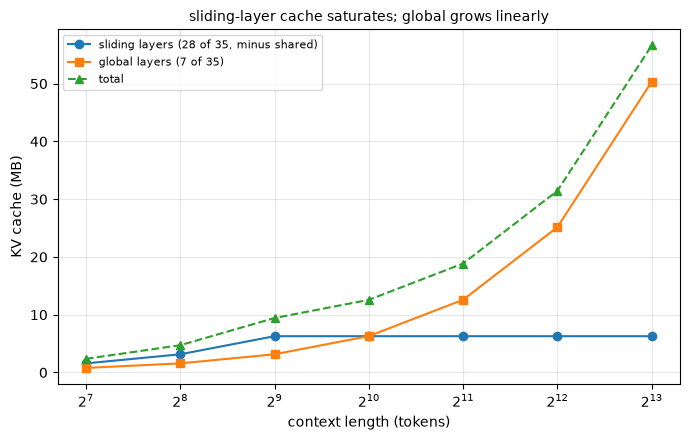

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sl = [per.get("DynamicSlidingWindowLayer", 0) / 1e6 for _, _, per in rows]
gl = [per.get("DynamicLayer", 0) / 1e6 for _, _, per in rows]
ax.plot(lengths, sl, marker="o", label="sliding layers (28 of 35, minus shared)")
ax.plot(lengths, gl, marker="s", label="global layers (7 of 35)")
ax.plot(lengths, [a + b for a, b in zip(sl, gl)], marker="^", ls="--", label="total")
ax.set_xscale("log", base=2); ax.set_xlabel("context length (tokens)")
ax.set_ylabel("KV cache (MB)"); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title("sliding-layer cache saturates; global grows linearly", fontsize=10)
plt.tight_layout(); plt.show()

**The sliding line goes flat.** Past `sliding_window` tokens those layers stop growing entirely — they physically cannot remember more than their window, so there is nothing to store. The global layers keep growing, and by 8K tokens they are the overwhelming majority of the cache.

That is the whole argument for the 5:1 mix, in megabytes rather than prose. It also tells you exactly which knob matters at long context: the number of global layers, not the total depth.

## 3. Batch scaling

In [6]:
def timed(inputs, n_new=32, **kw):
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=n_new, min_new_tokens=n_new,
                             do_sample=False, **kw)
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    n_tokens = (out.shape[-1] - inputs["input_ids"].shape[-1]) * out.shape[0]
    return dt, n_tokens

timed(make_batch("warm up"), 8)          # warm-up, discard

print(f"{'batch':>6} | {'wall time':>10} | {'tokens':>7} | {'throughput':>12}")
print("-" * 46)
results = []
for b in (1, 2, 4, 8, 16):
    dt, n = timed(make_batch("Write a detailed paragraph about the sea.", b), 32)
    results.append((b, dt, n / dt))
    print(f"{b:6d} | {dt:9.2f}s | {n:7d} | {n/dt:9.1f} t/s")

 batch |  wall time |  tokens |   throughput
----------------------------------------------


     1 |      2.55s |      32 |      12.6 t/s


     2 |      2.60s |      64 |      24.6 t/s


     4 |      2.60s |     128 |      49.2 t/s


     8 |      2.64s |     256 |      96.9 t/s


    16 |      2.65s |     512 |     193.5 t/s


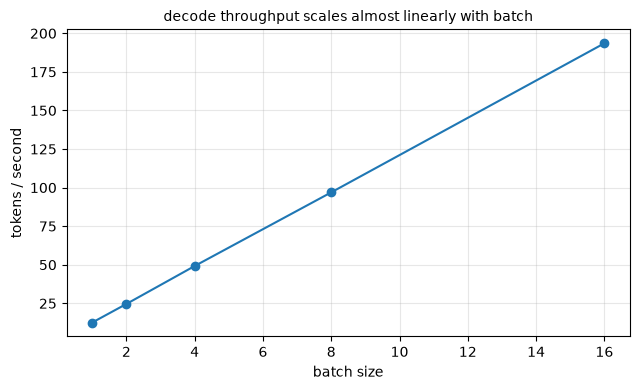

batch 1 -> 13 t/s;  batch 16 -> 194 t/s (15.4x)

Wall time barely moves. Decode is memory-bandwidth bound: you are already
paying to move the weights, so extra sequences ride along nearly free.
This is why serving engines batch aggressively — and why your single-user
latency is a bad predictor of your throughput.


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot([r[0] for r in results], [r[2] for r in results], marker="o")
ax.set_xlabel("batch size"); ax.set_ylabel("tokens / second"); ax.grid(alpha=.3)
ax.set_title("decode throughput scales almost linearly with batch", fontsize=10)
plt.tight_layout(); plt.show()

base = results[0][2]
print(f"batch 1 -> {base:.0f} t/s;  batch {results[-1][0]} -> {results[-1][2]:.0f} t/s "
      f"({results[-1][2]/base:.1f}x)")
print("\nWall time barely moves. Decode is memory-bandwidth bound: you are already")
print("paying to move the weights, so extra sequences ride along nearly free.")
print("This is why serving engines batch aggressively — and why your single-user")
print("latency is a bad predictor of your throughput.")

## 4. Static cache, measured honestly

`cache_implementation="static"` preallocates fixed-size buffers so `torch.compile` does not recompile on every new sequence length. The docs' first Gemma 4 example uses it. Here is what it actually costs.

In [8]:
inputs = make_batch("Write a detailed paragraph about the sea.")

dt_dyn, n = timed(inputs, 64)
print(f"dynamic cache        : {dt_dyn:6.2f}s  ({n/dt_dyn:5.1f} t/s)")

dt_static_cold, n = timed(inputs, 64, cache_implementation="static")
print(f"static, first call   : {dt_static_cold:6.2f}s  ({n/dt_static_cold:5.1f} t/s)  <- includes compilation")

dt_static_warm, n = timed(inputs, 64, cache_implementation="static")
print(f"static, second call  : {dt_static_warm:6.2f}s  ({n/dt_static_warm:5.1f} t/s)")

print(f"\ncompilation cost: about {dt_static_cold - dt_static_warm:.0f}s, paid once")
if dt_static_warm < dt_dyn:
    break_even = (dt_static_cold - dt_static_warm) / (dt_dyn - dt_static_warm)
    print(f"break-even after roughly {break_even:.0f} generations of this shape")
else:
    print("On this hardware and shape, static did not beat dynamic even warm.")
    print("Static cache is a torch.compile enabler, not a free win — measure before adopting.")

dynamic cache        :   5.15s  ( 12.4 t/s)


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


W0818 05:02:12.069000 14525 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


static, first call   : 109.80s  (  0.6 t/s)  <- includes compilation


static, second call  :   0.75s  ( 85.3 t/s)

compilation cost: about 109s, paid once
break-even after roughly 25 generations of this shape


The honest summary: **static cache is not a speed-up you switch on.** It removes the recompilation that would otherwise make `torch.compile` useless, and it costs a large one-off compile plus memory sized for your longest sequence. If you serve one request and exit, it is a pure loss. If you serve thousands of same-shaped requests, it is how you get compiled decode at all.

## 5. Streaming

In [9]:
from transformers import TextIteratorStreamer
from threading import Thread

inputs = make_batch("Name three sea creatures and one fact about each.")
streamer = TextIteratorStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True)
thread = Thread(target=model.generate,
                kwargs=dict(**inputs, max_new_tokens=120, do_sample=False, streamer=streamer))

t0 = time.perf_counter()
thread.start()
first_token_at, pieces = None, []
for piece in streamer:
    if first_token_at is None and piece.strip():
        first_token_at = time.perf_counter() - t0
    pieces.append(piece)
thread.join()

print("".join(pieces))
print(f"\ntime to first token: {first_token_at:.2f}s  (prefill + one decode step)")
print(f"total:               {time.perf_counter()-t0:.2f}s")

Here are three sea creatures and one fact about each:

1. **Dolphin:** They are highly intelligent mammals known for their complex social structures and the ability to communicate using a variety of clicks and whistles.
2. **Octopus:** They have three hearts and blue blood, and they are famous for their incredible camouflage abilities, allowing them to instantly change the color and texture of their skin to blend into their surroundings.
3. **Great White Shark:** They are apex predators known for their powerful hunting skills and are capable of swimming at very high speeds.

time to first token: 0.19s  (prefill + one decode step)
total:               9.19s


## 6. What thinking costs

`enable_thinking` is a chat-template argument, not a generation flag ([chapter 02](../../02-text-io/index.md) §5) — and the tokens it produces are **generated tokens**, counted against `max_new_tokens`.

In [10]:
QUESTION = "A shop sells pens at 3 for $4. How much do 17 pens cost?"

def run(enable_thinking, max_new_tokens):
    messages = [{"role": "user", "content": [{"type": "text", "text": QUESTION}]}]
    inp = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_dict=True,
        return_tensors="pt", enable_thinking=enable_thinking).to(model.device)
    input_len = inp["input_ids"].shape[-1]
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False)
    torch.cuda.synchronize()
    gen = out[0][input_len:]
    return (time.perf_counter() - t0, input_len, len(gen),
            processor.decode(gen, skip_special_tokens=True))

for flag in (False, True):
    dt, plen, glen, text = run(flag, 300)
    print(f"enable_thinking={str(flag):5s}  prompt={plen:4d}  generated={glen:4d}  {dt:5.2f}s")
    print(f"  {text.strip()[:220]}...\n")

print("Budget max_new_tokens with thinking in mind, or you will get truncated")
print("reasoning and no answer.")

enable_thinking=False  prompt=  29  generated= 300  24.74s
  Here's how to solve the problem:

**1. Find the unit price (cost per pen):**

* The shop sells 3 pens for $\$4$.
* Cost per pen = Total cost / Number of pens
* Cost per pen = $\$4 / 3$

**2. Calculate the cost for 17 pen...



enable_thinking=True   prompt=  36  generated= 300  24.68s
  thought
Here's a thinking process to solve the problem:

1.  **Understand the given information:**
    *   The shop sells pens at a rate of 3 pens for $4.

2.  **Determine the unit price (cost per pen):**
    *   Cost of...

Budget max_new_tokens with thinking in mind, or you will get truncated
reasoning and no answer.


## Exercises

1. Extrapolate the cache curve to 128K. How much KV cache would E2B need, and which layers own it?
2. Repeat section 2 with an image in the prompt. Does 280 image tokens cost the same cache as 280 text tokens?
3. Find the batch size at which throughput stops scaling on your GPU. What ran out first?
4. Measure prefill and decode separately: time a `max_new_tokens=1` call, then subtract it from a `max_new_tokens=N` call.
5. Load with `AutoModelForCausalLM` instead and re-run section 3. How much VRAM did dropping the towers save, and did throughput change?
6. Set `padding_side="right"` and compare batched output with `padding_side="left"`. You will get no exception — how would you have caught this in a test?

## Where next

[Chapter 10](../../10-finetuning/index.md) — changing the weights.